In [7]:
!py -3.10 ingestion.py

Jumlah data: 541909
  InvoiceNo StockCode  ... CustomerID         Country
0    536365    85123A  ...    17850.0  United Kingdom
1    536365     71053  ...    17850.0  United Kingdom
2    536365    84406B  ...    17850.0  United Kingdom
3    536365    84029G  ...    17850.0  United Kingdom
4    536365    84029E  ...    17850.0  United Kingdom

[5 rows x 8 columns]
Data berhasil diupload ke MinIO


In [4]:
!py -3.10 -m pip install pandas minio


[notice] A new release of pip available: 22.3.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from pyspark.sql import SparkSession

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Clustering") \
    .config("spark.jars.packages", 
            "org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.12.262") \
    .config("spark.hadoop.fs.s3a.access.key", "admin") \
    .config("spark.hadoop.fs.s3a.secret.key", "password") \
    .config("spark.hadoop.fs.s3a.endpoint", "http://localhost:9000") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false") \
    .getOrCreate()

In [3]:
df = spark.read.csv(
    "s3a://data-lake/processed/",
    header=True,
    inferSchema=True
)

df.show(5)

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|   536373|    21730|glass star froste...|       6|2010-12-01 09:02:00|     4.25|   17850.0|United Kingdom|
|   536390|   85099B|jumbo bag red ret...|     100|2010-12-01 10:19:00|     1.65|   17511.0|United Kingdom|
|   536398|    21980|pack of 12 red re...|      24|2010-12-01 10:52:00|     0.29|   13448.0|United Kingdom|
|   536407|    22632|hand warmer red p...|       6|2010-12-01 11:34:00|     1.85|   17850.0|United Kingdom|
|   536408|    22553|plasters in tin s...|      12|2010-12-01 11:41:00|     1.65|   14307.0|United Kingdom|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
only showing top 5 rows



In [4]:
from pyspark.sql.functions import max

max_date = df.select(max("InvoiceDate")).collect()[0][0]

print(max_date)

2011-12-09 12:50:00


In [5]:
from datetime import timedelta

reference_date = max_date + timedelta(days=1)

print(reference_date)

2011-12-10 12:50:00


In [6]:
from pyspark.sql.functions import col, sum, count, max, datediff, lit, to_timestamp

# Fix tipe tanggal
df = df.withColumn("InvoiceDate", to_timestamp(col("InvoiceDate")))

# Total Price
df = df.withColumn("TotalPrice", col("Quantity") * col("UnitPrice"))

# RFM
df_rfm = df.groupBy("CustomerID").agg(
    datediff(lit(reference_date), max("InvoiceDate")).alias("Recency"),
    count("InvoiceNo").alias("Frequency"),
    sum("TotalPrice").alias("Monetary")
)

df_rfm.show(5)

+----------+-------+---------+-----------------+
|CustomerID|Recency|Frequency|         Monetary|
+----------+-------+---------+-----------------+
|   16916.0|     24|      134|           548.73|
|   17884.0|      4|      111|           685.47|
|   13956.0|      6|      146|989.3199999999999|
|   13094.0|     22|       22|          1622.04|
|   12493.0|    166|       19|           362.79|
+----------+-------+---------+-----------------+
only showing top 5 rows



In [44]:
df_rfm.select("Recency").describe().show()
df_rfm.select("Frequency").describe().show()
df_rfm.select("Monetary").describe().show()

+-------+------------------+
|summary|           Recency|
+-------+------------------+
|  count|              4290|
|   mean| 93.12913752913752|
| stddev|100.00563338971459|
|    min|                 1|
|    max|               374|
+-------+------------------+

+-------+------------------+
|summary|         Frequency|
+-------+------------------+
|  count|              4290|
|   mean| 89.10955710955712|
| stddev|220.16166112998178|
|    min|                 1|
|    max|              7584|
+-------+------------------+

+-------+------------------+
|summary|          Monetary|
+-------+------------------+
|  count|              4290|
|   mean| 1604.492729603732|
| stddev| 4808.633540639214|
|    min|               2.9|
|    max|158949.56000000003|
+-------+------------------+



In [7]:
quantiles = df_rfm.approxQuantile(
    "Monetary",
    [0.95],
    0
)

print(quantiles)

[5227.48]


In [9]:
cap_value = quantiles[0]

In [10]:
from pyspark.sql.functions import when, col

df_rfm = df_rfm.withColumn(
    "Monetary_capped",
    when(
        col("Monetary") > cap_value,
        cap_value
    ).otherwise(col("Monetary"))
)

In [11]:
from pyspark.sql.functions import log1p, col

df_rfm = df_rfm.withColumn("Monetary_log", log1p(col("Monetary_capped")))
df_rfm = df_rfm.withColumn("Frequency_log", log1p(col("Frequency")))

In [12]:
df_rfm = df_rfm.dropna(subset=["Recency", "Frequency_log", "Monetary_log"])

In [13]:
from pyspark.ml.feature import VectorAssembler, StandardScaler

assembler = VectorAssembler(
    inputCols=["Recency", "Frequency_log", "Monetary_log"],
    outputCol="features"
)

df_vector = assembler.transform(df_rfm)

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaledFeatures",
    withStd=True,
    withMean=True
)

scaler_model = scaler.fit(df_vector)
df_scaled = scaler_model.transform(df_vector)

In [15]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

In [16]:
k_values = []
sse_list = []
silhouette_list = []

In [17]:
for k in range(2, 7):

    # Train model
    kmeans = KMeans(
        k=k,
        seed=1,
        featuresCol="scaledFeatures"
    )

    model = kmeans.fit(df_scaled)

    predictions = model.transform(df_scaled)

    # SSE / WCSS
    sse = model.summary.trainingCost

    # Silhouette
    evaluator = ClusteringEvaluator(
        featuresCol="scaledFeatures"
    )

    silhouette = evaluator.evaluate(predictions)

    # Simpan hasil
    k_values.append(k)
    sse_list.append(sse)
    silhouette_list.append(silhouette)

    print(f"===== k = {k} =====")
    print(f"SSE : {sse}")
    print(f"Silhouette : {silhouette}")
    print()

===== k = 2 =====
SSE : 6601.830989117429
Silhouette : 0.5918615535997738

===== k = 3 =====
SSE : 4415.286765152808
Silhouette : 0.5721258880066892

===== k = 4 =====
SSE : 3449.1274850046043
Silhouette : 0.5189759370614925

===== k = 5 =====
SSE : 2924.5676152714614
Silhouette : 0.5151916728773803

===== k = 6 =====
SSE : 2587.2919550200545
Silhouette : 0.46131839735331237



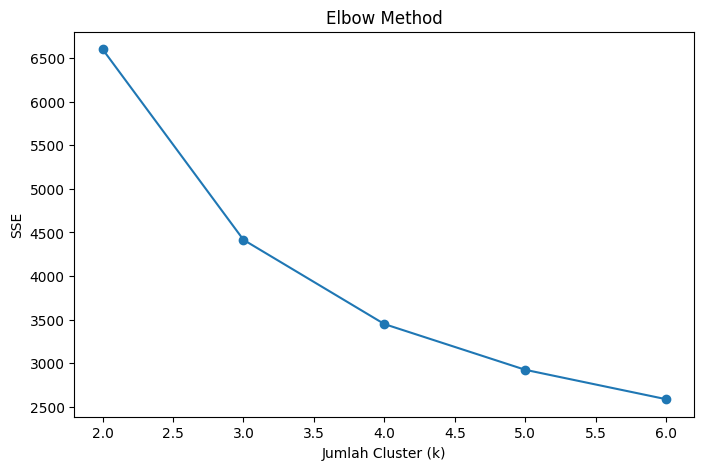

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    sse_list,
    marker='o'
)

plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("SSE")
plt.title("Elbow Method")

plt.show()

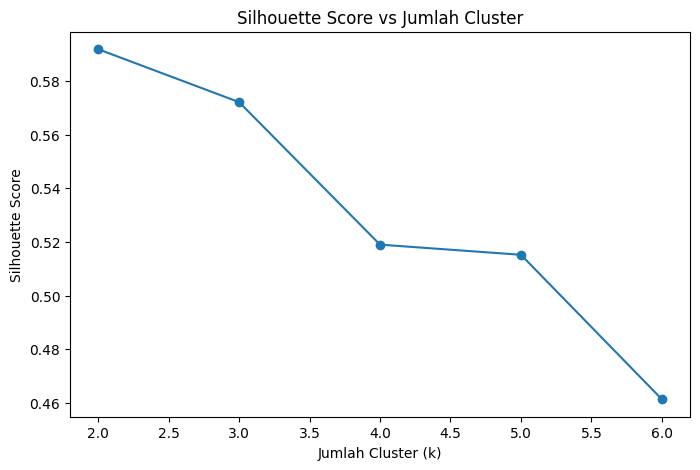

In [19]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_list,
    marker='o'
)

plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Jumlah Cluster")

plt.show()

In [20]:
from pyspark.ml.clustering import KMeans

kmeans = KMeans(
    k=3,
    seed=1,
    featuresCol="scaledFeatures"
)

model = kmeans.fit(df_scaled)

result = model.transform(df_scaled)

result.select("CustomerID", "prediction").show()

+----------+----------+
|CustomerID|prediction|
+----------+----------+
|   16916.0|         1|
|   17884.0|         1|
|   13956.0|         1|
|   13094.0|         2|
|   12493.0|         0|
|   13533.0|         0|
|   15776.0|         2|
|   17633.0|         1|
|   16629.0|         2|
|   14452.0|         2|
|   14473.0|         2|
|   13918.0|         2|
|   13607.0|         1|
|   14285.0|         1|
|   16596.0|         2|
|   18114.0|         0|
|   14768.0|         2|
|   14024.0|         2|
|   17267.0|         2|
|   13973.0|         0|
+----------+----------+
only showing top 20 rows



In [27]:
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator(featuresCol="scaledFeatures")

score = evaluator.evaluate(result)

print("Silhouette Score:", score)

Silhouette Score: 0.5721258880066892


In [21]:
result.groupBy("prediction").count().show()

result.groupBy("prediction").avg("Recency", "Frequency", "Monetary_capped").show()

+----------+-----+
|prediction|count|
+----------+-----+
|         1| 1680|
|         2| 1668|
|         0|  942|
+----------+-----+

+----------+------------------+------------------+--------------------+
|prediction|      avg(Recency)|    avg(Frequency)|avg(Monetary_capped)|
+----------+------------------+------------------+--------------------+
|         1|36.667857142857144|187.47559523809525|  2417.9910416666658|
|         2| 57.43225419664269|28.796163069544363|   458.9422721822541|
|         0|257.03290870488325|20.476645435244162|  325.50302547770673|
+----------+------------------+------------------+--------------------+



In [26]:
result_clean = result.select(
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary",
    "prediction"
)

result_clean.write \
    .mode("overwrite") \
    .csv("s3a://data-lake/gold/clustering/", header=True)

In [ ]:
!pip install matplotlib seaborn

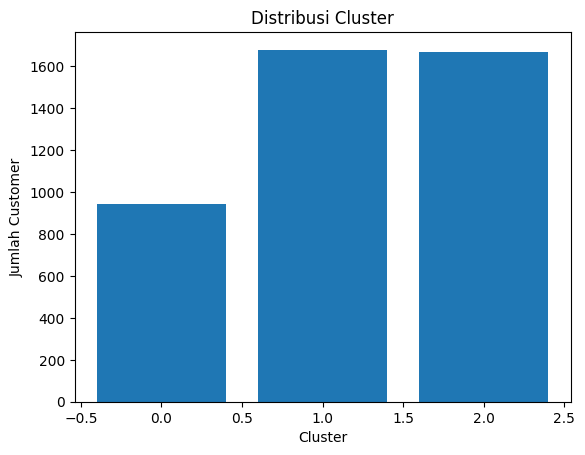

In [22]:
import matplotlib.pyplot as plt

cluster_counts = result.groupBy("prediction").count().toPandas()

plt.figure()
plt.bar(cluster_counts["prediction"], cluster_counts["count"])
plt.xlabel("Cluster")
plt.ylabel("Jumlah Customer")
plt.title("Distribusi Cluster")
plt.show()

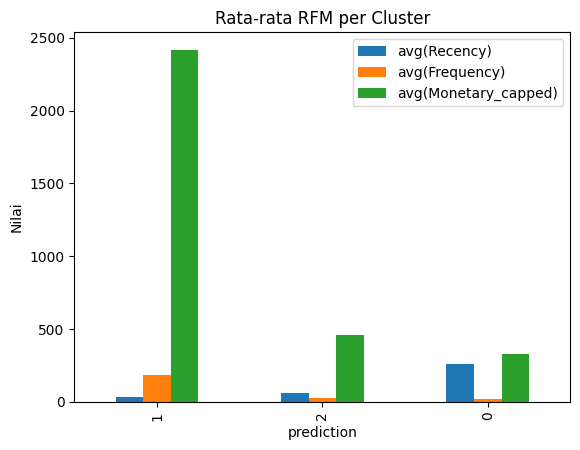

In [36]:
rfm_avg = result.groupBy("prediction") \
    .avg("Recency", "Frequency", "Monetary_capped") \
    .toPandas()

rfm_avg.set_index("prediction").plot(kind="bar")
plt.title("Rata-rata RFM per Cluster")
plt.ylabel("Nilai")
plt.show()

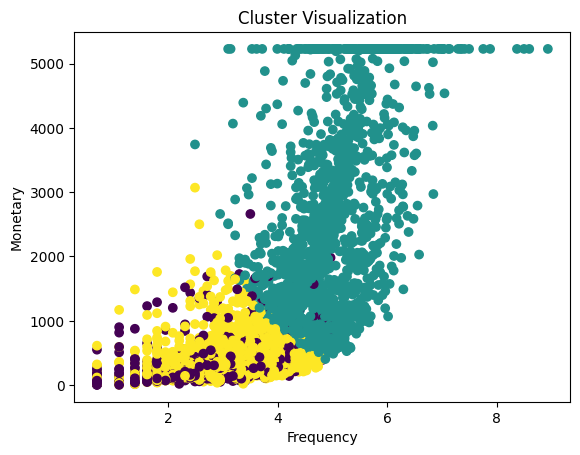

In [23]:
import matplotlib.pyplot as plt

df_plot = result.select("Frequency_log", "Monetary_capped", "prediction").toPandas()

plt.figure()
plt.scatter(
    df_plot["Frequency_log"],
    df_plot["Monetary_capped"],
    c=df_plot["prediction"]
)
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Cluster Visualization")
plt.show()

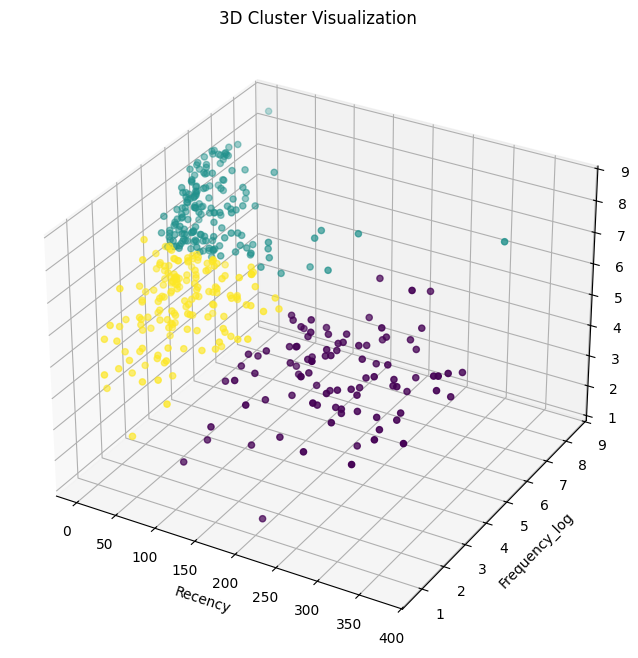

In [25]:
from mpl_toolkits.mplot3d import Axes3D

sample_df = result.select(
    "Recency",
    "Frequency_log",
    "Monetary_log",
    "prediction"
).sample(False, 0.1).toPandas()

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    sample_df["Recency"],
    sample_df["Frequency_log"],
    sample_df["Monetary_log"],
    c=sample_df["prediction"]
)

ax.set_xlabel("Recency")
ax.set_ylabel("Frequency_log")
ax.set_zlabel("Monetary_log")

ax.set_title("3D Cluster Visualization")

plt.show()

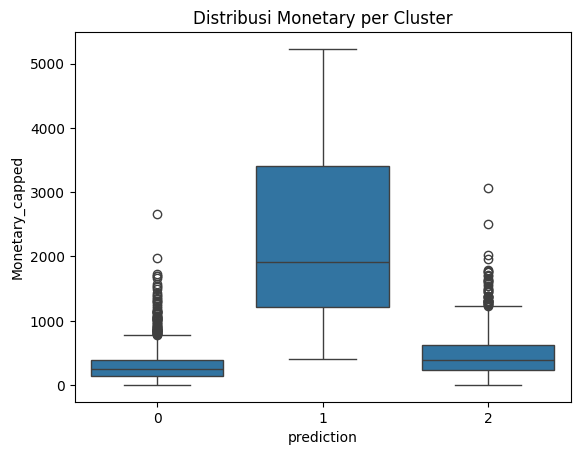

In [46]:
import seaborn as sns

df_plot = result.toPandas()

sns.boxplot(x="prediction", y="Monetary_capped", data=df_plot)
plt.title("Distribusi Monetary per Cluster")
plt.show()